# **An overview of Sliced Wasserstein distance with OTT-JAX**

# **I - Introduction**



Computing an optimal transport plan may be costly. Different strategies have been implemented during the last years. Our goal is to review some of them, especially the Sliced Wasserstein distance.

This notebook is divided into two main parts:

* Computation of different distances (exact Wasserstein distance, Sliced Wasserstein distance, Sliced Wasserstein Generalized Geodesics, Generalized Sliced Wasserstein Plan).
* Gradient flow experiments

# **II - Theoretical background**

The **wasserstein distance** is defined (in the discrete case) as:

$$
W(\mu,\nu)
=
\min_{P \in \mathbb{R}_+^{n \times m}}
\sum_{i,j} P_{ij} M_{ij}
\quad \text{s.c.} \quad
P \mathbf{1}_m = a, \;
P^\top \mathbf{1}_n = b
$$

An immediate drawback of this distance is that it is **costly to compute**. Then different strategies have been derived to handle this issue. One can quote for instance the idea of **adding regularization** (by subtracting an entropy term $-\alpha \sum_{i,j}P_{i,j}(\log(P_{ij})-1)$, and then deriving the Sinkhorn algorithm thanks to the Lagrangian optimality conditions, as introduced in 2013 by Marco Cuturi.

Another idea to handle the complexity is to reduce dimensionality by projections. This was introduced by Rabin, Julien et al. in 2011, with the **Sliced Wasserstein (SW) distance**, whose average is several 1D Wasserstein distances (useful because 1D Wasserstein distance just consists in sorting with a complexity of $O(n\log(n))$). The formal definition of it is:

$$
SW^{p}_{D}( \mu, \nu )
= \int_{\mathbb{S}^{d-1}}
W^{p}_{p}\big( P^{\#}_{\theta}\mu, P^{\#}_{\theta}\nu \big)\, d\lambda(\theta)
$$

where $P^{\#}_{\theta}$ denotes the projection plan along $\theta$.

One may identify two potential weakness of such a distance: 1. **Does not naturally introduced a transport plan**, 2. **It is a 1D distance, so differ from the original space**.

For these two reasons, Laetitia CHAPEL and al. have introduced two new distances linked to SW, **Sliced Wasserstein Generalized Geodesics**, and **Generalized Sliced Wasserstein Plan**

**The Sliced Wasserstein Generalized Geodesics (SWGG)** is defined as:
$$\min\text{-}\mathrm{SWGG}_p^p(\mu,\nu)
=
\min_{\theta \in \mathbb{S}^{d-1}}
\mathrm{SWGG}_p^p(\mu,\nu,\theta)
:=
\frac{1}{n}
\sum_{i=1}^n
\left\lVert
x_{\sigma_\theta(i)} - y_{\tau_\theta(i)}
\right\rVert_p^p$$

where $\sigma_\theta$ and, $\tau_\theta$ are the permutations obtained by sorting the projections $P^{\#}_{\theta}\mu$ and $P^{\#}_{\theta}\nu$.

This distance offer the possibility to deduce a transport plan, which is roughly the permutation in the case where the input $x$ is the same dimension as $y$. Another benefit is that we are back in the initial multidimensional space for computing the distance.

The **Generalized Sliced Wasserstein Plan** distance is build upon this idea of SWGG, but with a continuous map $\phi$, instead of projection along vectors.

$$\begin{aligned}
\mathrm{min\text{-}GSW}_p^p(\mu,\nu)
&= \min_{\theta \in \mathbb{R}^q} h(\theta)
:= f(\pi^\theta)
= \langle C_{\mu\nu}, \pi^\theta \rangle \\[0.5em]
&\text{subject to} \quad
\pi^\theta \in \arg\min_{\pi \in U(a,b)} g(\pi,\theta).
\end{aligned}$$

Unfortunatly, this expression is not differentiable making the minimization hard to compute. A basic solution consists in smoothing by introducing gaussian noise, as following:

$$h_\varepsilon(\theta) = \mathbb{E}_{z \sim \mathcal{N}(0,I)}[h(\theta + \varepsilon z)]$$

Its gradient is estimated via:
$$\nabla h_\varepsilon(\theta) \approx \frac{1}{\varepsilon N} \sum_{k=1}^N \bigl(h(\theta + \varepsilon z_k) - h(\theta)\bigr)\, z_k$$

# **III- Conputing distances**

In [92]:
pip install ott-jax

In [93]:
pip install pot

In [94]:
# import useful package
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import ot  # POT
from matplotlib.collections import LineCollection
from sklearn.datasets import make_moons
from jax import vmap
from jax import grad, jit, vmap
from ott.tools.sliced import sliced_wasserstein
from ott.geometry import costs, pointcloud
key=jax.random.PRNGKey(42)

## Creation of the datasets

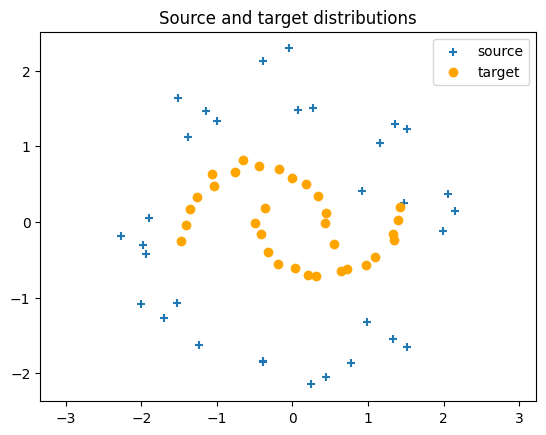

In [111]:
def make_8gaussians(n, key, radius=2.0, std=0.3):
    n_per = n // 8
    angles = jnp.linspace(0, 2*jnp.pi, 9)[:8]
    centers = radius * jnp.stack([jnp.cos(angles), jnp.sin(angles)], axis=1)
    keys = jax.random.split(key, 8)
    return jnp.concatenate([centers[i] + std*jax.random.normal(keys[i], (n_per, 2)) for i in range(8)])

def make_two_moons(n, noise=0.05, s=0.7):
    X, _ = make_moons(n_samples=n, noise=noise, random_state=0)
    X = (X - X.mean(axis=0)) / X.std()
    return jnp.array(s*X)

n_particles = 32
key, dk = jax.random.split(key)
X_source = make_8gaussians(n_particles, dk)
Y_target = make_two_moons(n_particles)

plt.scatter(*X_source.T, marker="+", label="source")
plt.scatter(*Y_target.T, c="orange", label="target")
plt.legend()
plt.axis("equal")
plt.title("Source and target distributions")
plt.show()

In [96]:
X = jnp.asarray(X_source)
Y = jnp.asarray(Y_target)
# Dimensions, note thate m=n
n = X.shape[0]
m = Y.shape[0]

a = jnp.ones(n) / n
b = jnp.ones(m) / m

# Euclidian cost matrix using ott-jax
geometry = pointcloud.PointCloud(X, Y)
C = geometry.cost_matrix

## Wasserstein distance

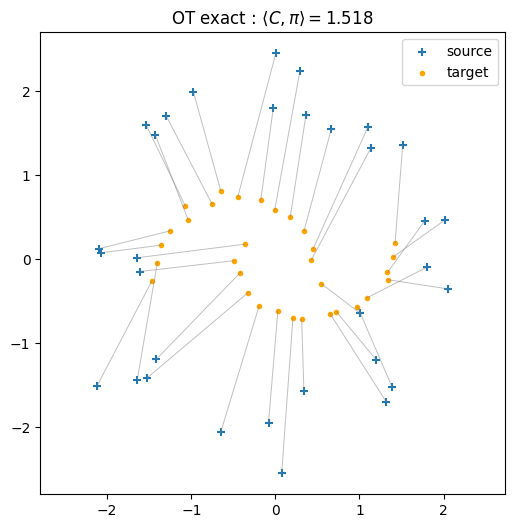

In [97]:
# plan OT exact
# Note: ot.emd expects numpy arrays, so convert back if using POT for exact EMD
P_exact = ot.emd(np.asarray(a), np.asarray(b), np.asarray(C))

#Exact Wasserstein distance
value_exact = jnp.sum(P_exact * C)
plt.figure(figsize=(6, 6))
plt.scatter(*X_source.T, marker="+", label="source")
plt.scatter(*Y_target.T, c="orange", marker=".", label="target")
threshold = 1e-12
for i in range(P_exact.shape[0]):
    for j in range(P_exact.shape[1]):
        if P_exact[i, j] > threshold:
            plt.plot(
                [X[i, 0], Y[j, 0]],
                [X[i, 1], Y[j, 1]],
                color="gray", alpha=0.5, lw=0.7
            )

plt.legend()
plt.title(rf"OT exact : $\langle C, \pi \rangle = {value_exact:.3f}$")
plt.axis("equal")
plt.show()

## SW distance

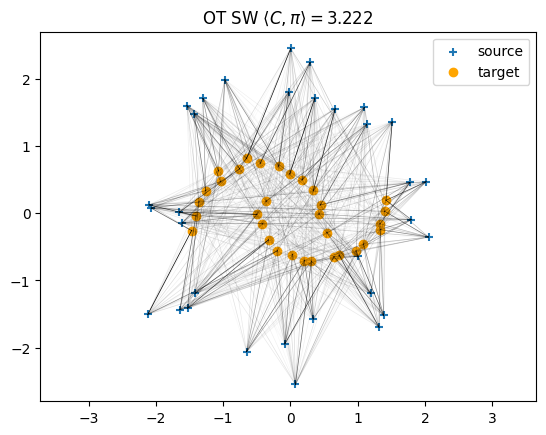

In [98]:
n_proj=100 #Number of random projections, that are going to be average

dist, out = sliced_wasserstein(
    X_source, Y_target,
    a=jnp.asarray(a), b=jnp.asarray(b),
    n_proj = n_proj,
    return_transport=True,
    rng=key
)


P = jnp.mean(out.transport_matrices.todense(), axis=0)
plt.scatter(*X_source.T, marker="+", label="source")
plt.scatter(*Y_target.T, c="orange", label="target")

for i in range(X_source.shape[0]):
    for j in range(Y_target.shape[0]):
        if P[i, j] > 1e-5:
            plt.plot([X_source[i, 0], Y_target[j, 0]],
                     [X_source[i, 1], Y_target[j, 1]],
                     c="black",
                     alpha=float(P[i, j] / P.max()),
                     lw=0.5)
#Cost in 2D
cost = np.sum(P * C)
plt.title(rf"OT SW $\langle C, \pi \rangle = {cost:.3f}$")
plt.legend()
plt.axis("equal")
plt.show()

## SWGG

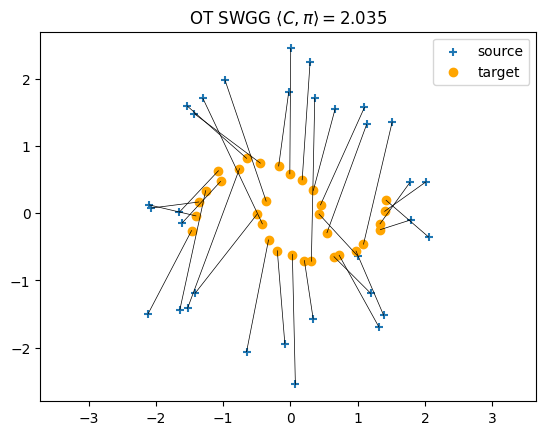

In [99]:
L = 100 #number of randomly selected projections direction
dist, out = sliced_wasserstein(
  X_source, Y_target,
  a=jnp.asarray(a), b=jnp.asarray(b),
  n_proj = L,
  return_transport=True,
  rng=key
)
# For SWGG, we focus directly on the 2D distance, rather 1D as in SW.
# We select the min
min_cost, P_min = min(
    ((np.sum(P * C), P) for P in out.transport_matrices.todense()),
    key=lambda x: x[0]
)

# Plot
plt.scatter(*X_source.T, marker="+", label="source")
plt.scatter(*Y_target.T, c="orange", label="target")
cost = np.sum(P_min * C)
for i in range(X_source.shape[0]):
    for j in range(Y_target.shape[0]):
        if P_min[i, j] > 1e-5:
            plt.plot([X_source[i, 0], Y_target[j, 0]],
                     [X_source[i, 1], Y_target[j, 1]],
                     c="black",
                     lw=0.5)
plt.title(rf"OT SWGG $\langle C, \pi \rangle = {min_cost:.3f}$")
plt.legend()
plt.axis("equal")
plt.show()

# **IV - Gradient Flow**

In [100]:
def SWGG_loss(X, Y, L, key):
    X_fixed = jax.lax.stop_gradient(X)
    Y_fixed = jax.lax.stop_gradient(Y)
    n, m = X.shape[0], Y.shape[0]
    a = jnp.ones((n,)) / n
    b = jnp.ones((m,)) / m
    dist, out = sliced_wasserstein(
        X_fixed, Y_fixed,
        a=a, b=b,
        n_proj=L,
        return_transport=True,
        rng=key
    )

    #Use ott.geometry.PointCloud for cost matrix calculation
    geometry_fixed = pointcloud.PointCloud(X_fixed, Y_fixed)
    C_fixed = geometry_fixed.cost_matrix

    def compute_transport_cost(P):
        return jnp.sum(P * C_fixed)
    all_Ps = out.transport_matrices.todense() # Format (L, N, M)
    costs_per_proj = vmap(compute_transport_cost)(all_Ps)
    best_idx = jnp.argmin(costs_per_proj)
    P_min = jax.lax.stop_gradient(all_Ps[best_idx])

    #Use ott.geometry.PointCloud for cost matrix calculation for the final cost
    geometry = pointcloud.PointCloud(X, Y)
    C = geometry.cost_matrix
    return jnp.sum(P_min * C)

#jax autodiff
swgg_grad_fn = jit(grad(SWGG_loss, argnums=0), static_argnums=(2,))

def sw_gradient_flow_step(X, Y, key, lr_X=0.8, L=1):
    """Updqte"""
    key, step_key = jax.random.split(key)
    #Compute gradient
    gX = swgg_grad_fn(X, Y, L, step_key)
    X_new = X - lr_X * gX
    cost = SWGG_loss(X, Y, L, step_key)
    return X_new, cost

# Parameters
n_flow_steps = 100
L = 100
learning_rate = 0.5

print("Starting SWGG Gradient Flow...")
X_sw = jnp.array(X_source)
Y_target = jnp.array(Y_target)
costs_sw = []
snapshots_sw = []
key = jax.random.PRNGKey(42)

for t in range(n_flow_steps):
    key, step_key = jax.random.split(key)
    X_sw, cost_val = sw_gradient_flow_step(X_sw, Y_target, step_key, lr_X=learning_rate, L=L)

    costs_sw.append(float(cost_val))
    # Display
    if t % 5 == 0:
        print(f" Step {t:3d} | SWGG cost = {cost_val:.4f}")

print("Flow complete!")

Starting SWGG Gradient Flow...
 Step   0 | SWGG cost = 2.0349
 Step   5 | SWGG cost = 1.4488
 Step  10 | SWGG cost = 1.0565
 Step  15 | SWGG cost = 0.9201
 Step  20 | SWGG cost = 0.5570
 Step  25 | SWGG cost = 0.4040
 Step  30 | SWGG cost = 0.4261
 Step  35 | SWGG cost = 0.2128
 Step  40 | SWGG cost = 0.1541
 Step  45 | SWGG cost = 0.1320
 Step  50 | SWGG cost = 0.0786
 Step  55 | SWGG cost = 0.0602
 Step  60 | SWGG cost = 0.0443
 Step  65 | SWGG cost = 0.0325
 Step  70 | SWGG cost = 0.0237
 Step  75 | SWGG cost = 0.0172
 Step  80 | SWGG cost = 0.0125
 Step  85 | SWGG cost = 0.0091
 Step  90 | SWGG cost = 0.0066
 Step  95 | SWGG cost = 0.0048
Flow complete!


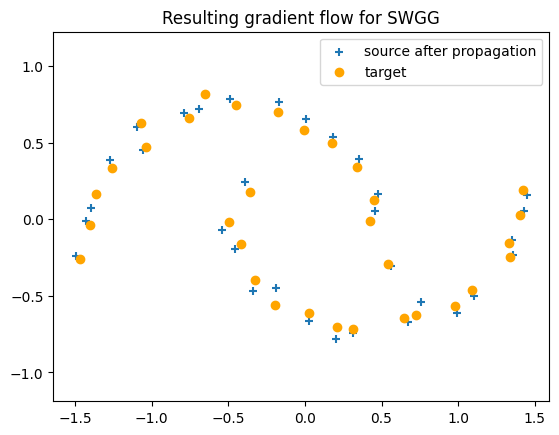

In [117]:
plt.scatter(*X_sw.T, marker="+", label="source after propagation")
plt.scatter(*Y_target.T, c="orange", label="target")
plt.title(rf"Resulting gradient flow for SWGG")
plt.legend()
plt.axis("equal")
plt.show()

In [102]:
def find_optimal_theta(X, Y, key, lr=0.05, n_steps=200, eps=0.1, N=50):
    # Gradient descent on h_eps(theta) to find the min-GSWP direction.
    d = X.shape[1]
    key, init_key = jax.random.split(key)
    theta = jax.random.normal(init_key, (d,))
    theta = theta / jnp.linalg.norm(theta)
    for step in range(n_steps):
        key, subkey = jax.random.split(key)
        Z = jax.random.normal(subkey, (N, d))
        h_perturbed = vmap(lambda t: sliced_wasserstein(X, Y, proj_fn=lambda x: x @ t[:, None])[0])(theta[None, :] + eps * Z)
        h0 = sliced_wasserstein(X, Y, proj_fn=lambda x: x @ theta[:, None])[0]
        grad_est = jnp.mean((h_perturbed - h0)[:, None] * Z, axis=0) / eps
        theta = theta - lr * grad_est
        theta = theta / jnp.linalg.norm(theta)
    return theta

# Gradient of h w.r.t. X (for particle updates) via JAX autodiff
def DSWG(X, Y, theta):
    X_fixed = jax.lax.stop_gradient(X)
    Y_fixed = jax.lax.stop_gradient(Y)
    n, m = X.shape[0], Y.shape[0]
    a = jnp.ones((n,)) / n
    b = jnp.ones((m,)) / m
    dist, out = sliced_wasserstein(
        X_fixed, Y_fixed,
        a=a, b=b,
        proj_fn=lambda x: x @ theta[:, None],
        return_transport=True,
    )
    P = jax.lax.stop_gradient(out.transport_matrices.todense())

    # Use ott.geometry.PointCloud for cost matrix calculation
    geometry = pointcloud.PointCloud(X, Y)
    C = geometry.cost_matrix
    return jnp.sum(P * C)

grad_X_fn = jit(grad(DSWG, argnums=0))
n_flow_steps = 100
learning_rate = 0.5
X_dgswp = X_source
costs_dgswp, snapshots_dgswp, thetas_flow = [], [], []

print("Running DGSWP gradient flow...")
for t in range(n_flow_steps):
    key, step_key = jax.random.split(key)
    theta_t = find_optimal_theta(X_dgswp, Y_target, step_key,
                                     lr=0.05, n_steps=10, eps=0.05, N=20)
    gX = grad_X_fn(X_dgswp, Y_target, theta_t)
    cost_t = float(DSWG(X_dgswp, Y_target, theta_t))
    X_dgswp = X_dgswp - learning_rate * gX
    costs_dgswp.append(cost_t)
    thetas_flow.append(theta_t)
    if t % 5 == 0:
        print(f"  Step {t:3d} | cost = {cost_t:.4f}")
print("Flow complete!")
X_dgswp_final = X_dgswp

Running DGSWP gradient flow...
  Step   0 | cost = 2.9538
  Step   5 | cost = 2.5271
  Step  10 | cost = 1.8055
  Step  15 | cost = 1.4235
  Step  20 | cost = 0.9573
  Step  25 | cost = 1.0319
  Step  30 | cost = 0.6571
  Step  35 | cost = 1.2269
  Step  40 | cost = 0.8691
  Step  45 | cost = 0.4775
  Step  50 | cost = 0.7025
  Step  55 | cost = 0.7455
  Step  60 | cost = 0.2252
  Step  65 | cost = 0.2671
  Step  70 | cost = 0.3945
  Step  75 | cost = 0.3618
  Step  80 | cost = 0.7341
  Step  85 | cost = 0.4285
  Step  90 | cost = 0.6548
  Step  95 | cost = 0.7129
Flow complete!


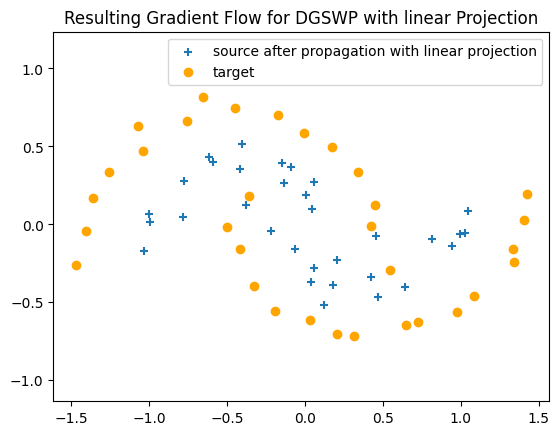

In [114]:
plt.scatter(*X_dgswp_final.T, marker="+", label="source after propagation with linear projection")
plt.scatter(*Y_target.T, c="orange", label="target")
plt.title(rf"Resulting Gradient Flow for DGSWP with linear Projection")
plt.legend()
plt.axis("equal")
plt.show()

## **IV-ii DSWGG (Neural Network)**

Instead of a simple linear projection $\theta$, we can use a more complex, learnable function $\phi_w(x)$ parameterized by weights $w$ (e.g., a Neural Network). The goal is to find optimal weights $w$ for the network at each step of the gradient flow.

First, let's define a simple Multi-Layer Perceptron (MLP) using `jax.experimental.stax` to act as our $\phi$ function. This network will take a 2D input and output a 1D projection.

In [104]:
import flax.linen as nn
import optax # Used for parameter updates

# Define a simple MLP architecture for phi using Flax
class MLP(nn.Module):
    hidden_dim: int = 64

    @nn.compact
    def __call__(self, x):
        # Use explicit initializers for robustness
        kernel_init = nn.initializers.glorot_uniform()
        bias_init = nn.initializers.normal(stddev=0.1) # Small non-zero biases

        x = nn.Dense(self.hidden_dim, kernel_init=kernel_init, bias_init=bias_init)(x)
        x = nn.relu(x)
        x = nn.Dense(self.hidden_dim, kernel_init=kernel_init, bias_init=bias_init)(x)
        x = nn.relu(x)
        x = nn.Dense(1, kernel_init=kernel_init, bias_init=bias_init)(x) # Output a 1D projection
        return x

# Initialize the NN parameters
key, nn_key = jax.random.split(key)
input_dim = X_source.shape[1] # 2D points

# Instantiate the model
nn_model = MLP(hidden_dim=64)

# Initialize parameters
# Provide a dummy input to the init function to infer shapes
dummy_input = jnp.ones((1, input_dim))
nn_params = nn_model.init(nn_key, dummy_input)['params'] # Flax returns a dict, we want 'params'

print(f"Neural Network parameters initialized: {jax.tree_util.tree_map(lambda x: x.shape, nn_params)}")

Neural Network parameters initialized: {'Dense_0': {'bias': (64,), 'kernel': (2, 64)}, 'Dense_1': {'bias': (64,), 'kernel': (64, 64)}, 'Dense_2': {'bias': (1,), 'kernel': (64, 1)}}


Next, we'll create a function `find_optimal_nn_phi` that optimizes the neural network's parameters at each step. This optimization is nested within the main gradient flow, as $\phi$ depends on the current source distribution $X$.

In [105]:
def find_optimal_nn_phi(X, Y, key, initial_nn_params, nn_model_apply_fn, lr_phi=0.01, n_phi_steps=50):
    # This function optimizes the NN parameters `nn_params` to find the optimal projection `phi`.

    @jit
    def phi_loss_fn(current_nn_params, X_data, Y_data, phi_key):
        # Calculate SW distance using the current NN parameters as proj_fn
        proj_fn_nn = lambda z: nn_model_apply_fn({'params': current_nn_params}, z) # Ensure 1D output is (batch_size, 1)
        sw_dist, _ = sliced_wasserstein(
            X_data, Y_data,
            proj_fn=proj_fn_nn,
        )
        return sw_dist

    # Get the gradient of the loss with respect to nn_params
    grad_phi_loss_fn = jit(grad(phi_loss_fn))

    current_nn_params = initial_nn_params
    # Using optax for a more robust optimizer, e.g., Adam
    optimizer = optax.adam(lr_phi)
    opt_state = optimizer.init(current_nn_params)

    # print(f"  Starting NN parameter optimization (inner loop)...")
    for step in range(n_phi_steps):
        key, phi_step_key = jax.random.split(key)
        grads = grad_phi_loss_fn(current_nn_params, X, Y, phi_step_key)
        updates, opt_state = optimizer.update(grads, opt_state, current_nn_params)
        current_nn_params = optax.apply_updates(current_nn_params, updates)

        # # Optional: print cost during inner optimization
        # if step % (n_phi_steps // 5) == 0 or step == n_phi_steps - 1:
        #     phi_cost = phi_loss_fn(current_nn_params, X, Y, phi_step_key)
        #     print(f"    NN Opt Step {step:3d} | Phi cost = {phi_cost:.4f}")

    return current_nn_params

Now, we adapt the `DSWG` function to use the neural network for projection and then set up a new gradient flow loop.

In [106]:
# Gradient of h w.r.t. X (for particle updates) using NN projection
def DSWG_NN_proj(X, Y, nn_params, nn_model_apply_fn):
    X_fixed = jax.lax.stop_gradient(X)
    Y_fixed = jax.lax.stop_gradient(Y)
    n, m = X.shape[0], Y.shape[0]
    a = jnp.ones((n,)) / n
    b = jnp.ones((m,)) / m

    # Define the projection function using the NN's apply_fn and optimized parameters
    proj_fn_nn = lambda z: nn_model_apply_fn({'params': nn_params}, z) # Ensure 1D output is (batch_size, 1)

    dist, out = sliced_wasserstein(
        X_fixed, Y_fixed,
        a=a, b=b,
        proj_fn=proj_fn_nn,
        return_transport=True,
    )
    P = jax.lax.stop_gradient(out.transport_matrices.todense())

    # Use ott.geometry.PointCloud for cost matrix calculation
    geometry = pointcloud.PointCloud(X, Y)
    C = geometry.cost_matrix
    return jnp.sum(P * C)

grad_X_fn_nn = jit(grad(DSWG_NN_proj, argnums=0), static_argnums=(3,))

# Parameters for the DGSWP-NN gradient flow
n_flow_steps_nn = 100
learning_rate_X_nn = 0.5# Learning rate for updating X
lr_phi_nn = 0.005 # Learning rate for optimizing NN parameters
n_phi_opt_steps = 10 # Number of steps to optimize NN parameters at each flow step

X_dgswp_nn = X_source # Initialize source for NN flow
costs_dgswp_nn = []
optimized_nn_params_history = [nn_params] # Store history of NN parameters

print("\nRunning DGSWP Gradient Flow with Neural Network Projection...")
current_nn_params = nn_params # Start with initially random NN params

for t in range(n_flow_steps_nn):
    key, step_key, phi_opt_key = jax.random.split(key, 3)

    # 1. Optimize NN parameters (phi) for the current X_dgswp_nn and Y_target
    optimized_nn_params = find_optimal_nn_phi(
        X_dgswp_nn, Y_target, phi_opt_key,
        current_nn_params, nn_model.apply, lr_phi=lr_phi_nn, n_phi_steps=n_phi_opt_steps
    )
    optimized_nn_params_history.append(optimized_nn_params)
    current_nn_params = optimized_nn_params # Update current_nn_params for next iteration

    # 2. Compute gradient for X using the optimized NN projection
    gX_nn = grad_X_fn_nn(X_dgswp_nn, Y_target, optimized_nn_params, nn_model.apply)
    cost_t_nn = float(DSWG_NN_proj(X_dgswp_nn, Y_target, optimized_nn_params, nn_model.apply))

    # 3. Update X_dgswp_nn
    X_dgswp_nn = X_dgswp_nn - learning_rate_X_nn * gX_nn

    costs_dgswp_nn.append(cost_t_nn)

    if t % 5 == 0 or t == n_flow_steps_nn -1:
        print(f"  Flow Step {t:3d} | DGSWP-NN cost = {cost_t_nn:.4f}")

print("DGSWP-NN Flow complete!")
X_dgswp_nn_final = X_dgswp_nn


Running DGSWP Gradient Flow with Neural Network Projection...
  Flow Step   0 | DGSWP-NN cost = 2.7451
  Flow Step   5 | DGSWP-NN cost = 3.0080
  Flow Step  10 | DGSWP-NN cost = 3.1384
  Flow Step  15 | DGSWP-NN cost = 1.2456
  Flow Step  20 | DGSWP-NN cost = 1.0564
  Flow Step  25 | DGSWP-NN cost = 0.8776
  Flow Step  30 | DGSWP-NN cost = 1.6375
  Flow Step  35 | DGSWP-NN cost = 0.9190
  Flow Step  40 | DGSWP-NN cost = 0.7706
  Flow Step  45 | DGSWP-NN cost = 0.9929
  Flow Step  50 | DGSWP-NN cost = 1.2170
  Flow Step  55 | DGSWP-NN cost = 0.8420
  Flow Step  60 | DGSWP-NN cost = 0.8296
  Flow Step  65 | DGSWP-NN cost = 0.9589
  Flow Step  70 | DGSWP-NN cost = 1.0216
  Flow Step  75 | DGSWP-NN cost = 0.7542
  Flow Step  80 | DGSWP-NN cost = 0.7084
  Flow Step  85 | DGSWP-NN cost = 0.8319
  Flow Step  90 | DGSWP-NN cost = 0.8060
  Flow Step  95 | DGSWP-NN cost = 0.9148
  Flow Step  99 | DGSWP-NN cost = 0.9802
DGSWP-NN Flow complete!


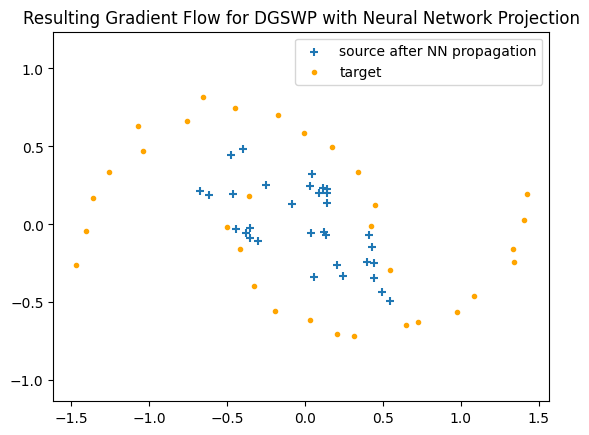

In [115]:
plt.scatter(*X_dgswp_nn_final.T, marker="+", label="source after NN propagation")
plt.scatter(*Y_target.T, c="orange", marker=".", label="target")
plt.title(r"Resulting Gradient Flow for DGSWP with Neural Network Projection")
plt.legend()
plt.axis("equal")
plt.show()

### Comparison of Costs

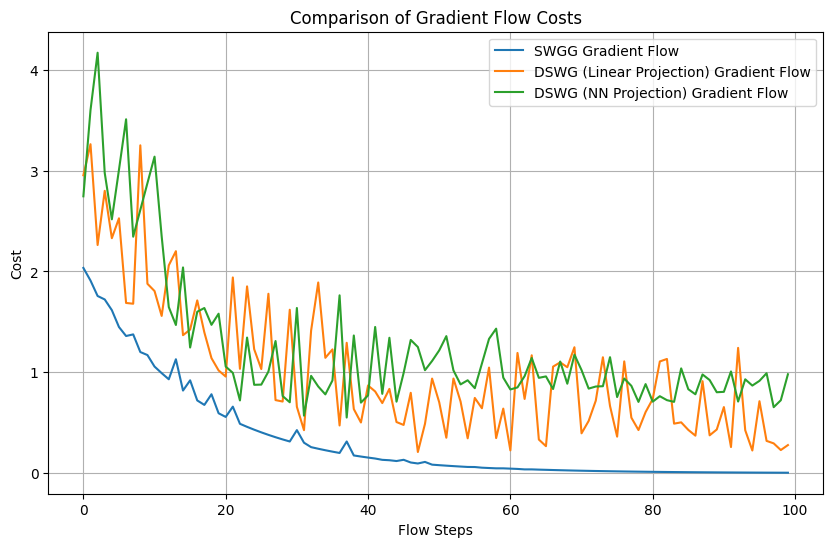

In [116]:
plt.figure(figsize=(10, 6))
plt.plot(costs_sw, label='SWGG Gradient Flow')
plt.plot(costs_dgswp, label='DSWG (Linear Projection) Gradient Flow')
plt.plot(costs_dgswp_nn, label='DSWG (NN Projection) Gradient Flow')
plt.xlabel('Flow Steps')
plt.ylabel('Cost')
plt.title('Comparison of Gradient Flow Costs')
plt.legend()
plt.grid(True)
plt.show()

# **References**

* [Sinkhorn Distances: Lightspeed Computation of Optimal Transportation Distances](https://arxiv.org/abs/1306.0895), Marco Cuturi, 2013.
* [Wasserstein Barycenter and its Application to Texture Mixing](https://hal.science/hal-00476064v1/document), Rabin Julien, Gabriel Peyré, Julie Delon, Bernot Marc, 2011
*  [Differentiable Generalized Sliced Wasserstein Plans](https://arxiv.org/abs/2505.22049), Laetitia Chapel and Romain Tavenard and Samuel Vaiter, 2025.
